In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from IPython.display import display
from plotting_utils import create_df_runs, flatten_runs_to_children
import numpy as np
import bambi as bmb
import arviz as az
import itertools
from typing import Tuple, Optional
import xarray as xr
from scipy.special import expit
from scipy.stats import norm
from collections.abc import Mapping
from typing import Any

import itertools
import numpy as np
import pandas as pd
import arviz as az

In [2]:


def flatten_run_row_children_indeterminate(row) -> list[dict[str, Any]]:
    """
    Extracts data at the child-level.
    A case with 3 children will return 3 dictionaries.
    """
    run_name = row.run_name
    timestamp_str = run_name.split("__")[0]

    model_string = str(row.model)
    if model_string.lower() == "unknown":
        return []

    results = row.results
    if not isinstance(results, Mapping):
        return []

    output = []

    for case_id, case_data in results.items():
        if case_id == "run_config":
            continue

        duration = case_data.get("duration_seconds")
        if duration is None:
            continue

        # Grab the child_evaluations dictionary (defaulting to an empty dict if missing)
        child_results = case_data.get("child_evaluations", {})

        # Handle if the evaluator stores children as a list of dictionaries
        if isinstance(child_results, list):
            for child in child_results:
                output.append(
                    {
                        "run_name": run_name,
                        "timestamp": pd.to_datetime(timestamp_str),
                        "config_label": row.config_label,
                        "run_type" : row.run_type,
                        "rules_type": row.rules_type,
                        "case_id": case_id,
                        "child_id": child.get("child_id", child.get("name", "unknown")),
                        "child_is_correct": int(child.get("is_correct", False)),
                        "duration": float(duration),
                    }
                )

        # Handle if the evaluator stores children as a dictionary {child_id: {data}}
        elif isinstance(child_results, dict):
            for child_id, child_data in child_results.items():
                output.append(
                    {
                        "run_name": run_name,
                        "timestamp": pd.to_datetime(timestamp_str),
                        "config_label": row.config_label,
                        "run_type" : row.run_type,
                        "rules_type": row.rules_type,
                        "case_id": case_id,
                        "child_id": child_id,  # e.g., "Alex", "Blake"
                        "child_is_correct": int(child_data.get("is_correct", False)),
                        "duration": float(duration),
                    }
                )

    return output

def flatten_runs_to_children_indeterminate(df_runs: pd.DataFrame) -> pd.DataFrame:
    """
    Creates a DataFrame where every row is an individual child's evaluation.
    """
    flat_data = [
        record
        for row in df_runs.itertuples(index=False)
        for record in flatten_run_row_children_indeterminate(row)
    ]

    return pd.DataFrame(flat_data)


In [3]:
def prep_data_for_reg(df: pd.DataFrame) -> pd.DataFrame:

    """
    Split the config_label into independent columns
    Using a regex split to safely handle the pipe character and surrounding spaces

    Ensure the outcome is an integer (Bambi expects 0/1 for bernoulli)
    """
    df[['model_name', 'prompt_type']] = df['config_label'].str.split(r'\s+\|\s+', expand=True)

    df['child_is_correct'] = df['child_is_correct'].astype(int)

    return df

In [4]:

def fit_bayesian_logistic_mixed_model(
    df: pd.DataFrame,
    formula: str = "child_is_correct ~ 0 + prompt_type + model_name + (1|case_id)",
    *,
    draws: int = 2000,
    tune: int = 1000,
    chains: int = 4,
    target_accept: float = 0.9,
    family: str = "bernoulli",
    random_seed: Optional[int] = None,
    progressbar: bool = True,
) -> Tuple[bmb.Model, az.InferenceData]:
    """
    Fit a Bayesian logistic mixed-effects model using Bambi.

    This function fits a Bernoulli (logistic) model with optional random effects,
    returning both the compiled Bambi model and the sampled posterior.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataset. Must contain all variables referenced in `formula`.

    formula : str, default="child_is_correct ~ 0 + prompt_type + model_name + (1|case_id)"
        Model formula in Bambi syntax.
        Example interpretation:
        - '0 + prompt_type' estimates a separate coefficient for each prompt type
          (no global intercept).
        - 'model_name' controls for differences between base models.
        - '(1|case_id)' adds a random intercept to account for clustering by case.

    draws : int, default=2000
        Number of posterior samples per chain.

    tune : int, default=1000
        Number of tuning (warm-up) iterations per chain.

    chains : int, default=4
        Number of MCMC chains.

    target_accept : float, default=0.9
        Target acceptance probability for the NUTS sampler (must be between 0 and 1).
        Higher values can improve sampling stability for hierarchical models.

    family : str, default="bernoulli"
        Likelihood family. For binary outcomes, use "bernoulli".

    random_seed : Optional[int], default=None
        Random seed for reproducibility.

    progressbar : bool, default=True
        Whether to display sampling progress.

    Returns
    -------
    model : bmb.Model
        The compiled Bambi model object.

    idata : az.InferenceData
        Posterior samples and diagnostics in ArviZ format.

    Notes
    -----
    - This model is typically used to estimate differences between prompt types
      while controlling for model-level effects and clustering by case.
    - Posterior comparisons (e.g. differences between prompt types) can be computed
      directly from `idata` rather than relying on post-hoc frequentist tests.
    """

    print("Building the Bayesian model...")
    model = bmb.Model(formula, df, family=family)

    print("Sampling the posterior (this may take a few minutes)...")
    idata = model.fit(
        draws=draws,
        tune=tune,
        chains=chains,
        target_accept=target_accept,
        random_seed=random_seed,
        progressbar=progressbar,
    )

    return model, idata

In [5]:
def summarise_model_results(
    idata: az.InferenceData,
    df: pd.DataFrame,
    *,
    main_var: str = "run_type",
    control_var: Optional[str] = "rules_type",
    round_to: int = 3,
) -> Tuple[pd.DataFrame, pd.DataFrame, xr.DataArray]:
    """
    Summarise a fitted Bayesian model and compute pairwise comparisons between levels of the main variable.

    Parameters
    ----------
    idata : az.InferenceData
        Posterior samples returned by Bambi/PyMC.

    df : pd.DataFrame
        Original dataset used for modelling. Used to extract unique labels for the main variable.

    main_var : str, default="run_type"
        Name of the primary coefficient to compute pairwise comparisons for.

    control_var : str, default="rules_type"
        Name of the secondary/control coefficient to include in the ArviZ summary.

    round_to : int, default=3
        Number of decimal places for rounding summary outputs.

    Returns
    -------
    summary_df : pd.DataFrame
        ArviZ summary table for selected coefficients.

    pairwise_df : pd.DataFrame
        Pairwise comparison table with:
        - level_a
        - level_b
        - prob_a_beats_b
        - winner
        - loser
        - prob_winner
        
    posterior : xr.DataArray
        Posterior samples for the main_var coefficients.
    """

    # ==========================================
    # Model summary
    # ==========================================
    print("\n--- Model Summary ---")
    vars_to_summarise = [main_var]
    if control_var:
        vars_to_summarise.append(control_var)
        
    summary_df = az.summary(idata, var_names=vars_to_summarise).round(round_to)
    print(summary_df)

    # ==========================================
    # Pairwise comparisons
    # ==========================================
    print(f"\n--- Pairwise Comparisons for '{main_var}' ---")

    posterior: xr.DataArray = idata.posterior[main_var]

    levels = df[main_var].unique()

    results = []

    for p1, p2 in itertools.combinations(levels, 2):
        # Bambi appends '_dim' to categorical dimension names in the posterior
        samples_p1 = posterior.sel({f"{main_var}_dim": p1}).values
        samples_p2 = posterior.sel({f"{main_var}_dim": p2}).values

        prob_p1_better = np.mean(samples_p1 > samples_p2)

        if prob_p1_better > 0.5:
            winner, loser, prob = p1, p2, prob_p1_better
        else:
            winner, loser, prob = p2, p1, 1 - prob_p1_better

        print(f"Probability '{winner}' outperforms '{loser}': {prob * 100:.1f}%")

        results.append(
            {
                "level_a": p1,
                "level_b": p2,
                "prob_a_beats_b": prob_p1_better,
                "winner": winner,
                "loser": loser,
                "prob_winner": prob,
            }
        )

    pairwise_df = pd.DataFrame(results)

    return summary_df, pairwise_df, posterior

In [6]:


def compute_odds_ratios(
    idata: az.InferenceData,
    df: pd.DataFrame,
    *,
    main_var: str = "run_type",
    round_to: int = 2,
    print_results: bool = True,
) -> pd.DataFrame:
    """
    Compute pairwise effect sizes (odds ratios) between levels of the main variable,
    accounting for the reference/baseline level.
    """

    if print_results:
        print(f"\n--- Effect Sizes (Odds Ratios) for '{main_var}' ---")

    posterior = idata.posterior[main_var]
    
    # Get all unique levels from the original dataframe
    levels = df[main_var].unique()
    dim_name = f"{main_var}_dim" 
    
    # Identify which levels actually exist in the posterior
    posterior_levels = posterior.coords[dim_name].values.tolist()

    results = []

    for p1, p2 in itertools.combinations(levels, 2):
        
        # Fetch samples, defaulting to 0.0 if it's the reference baseline
        if p1 in posterior_levels:
            samples_p1 = posterior.sel({dim_name: p1}).values
        else:
            samples_p1 = 0.0
            
        if p2 in posterior_levels:
            samples_p2 = posterior.sel({dim_name: p2}).values
        else:
            samples_p2 = 0.0

        # Calculate odds ratios
        odds_ratio_samples = np.exp(samples_p1 - samples_p2)

        median_or = np.median(odds_ratio_samples)
        lower = np.percentile(odds_ratio_samples, 2.5)
        upper = np.percentile(odds_ratio_samples, 97.5)

        if print_results:
            print(
                f"'{p1}' vs '{p2}': "
                f"Median OR = {median_or:.{round_to}f} "
                f"[{lower:.{round_to}f}, {upper:.{round_to}f}]"
            )

        results.append(
            {
                "level_a": p1,
                "level_b": p2,
                "median_odds_ratio": median_or,
                "lower_95": lower,
                "upper_95": upper,
            }
        )

    return pd.DataFrame(results)

In [7]:
run_names = ["facts_bundle_indeterminacy_concat_cases", "structured_spec_factBundle_reruns", "structured_spec_conversational_reruns", "indeterminacy_concat_cases_reruns"]
df_runs_list = [create_df_runs(hypothesis_to_filter= run_name) for run_name in run_names]
df_runs = pd.concat(df_runs_list, ignore_index=True)

df_runs created and its head looks like this:


,level_0,index,run_name,model,prompt,url_allowed,commit,hypothesis_name,results,prompt_name,prompt_type,model_name,config_key,prompt_version,config_label
0,35,36,2026-05-29T12:47:32.581873__Model=claude-sonne...,eu.anthropic.claude-sonnet-4-5-20250929-v1:0,agents/TechnicalHypotheses/Accuracy-ChildBenef...,False,7f86bad1,facts_bundle_indeterminacy_concat_cases,{'APPRENTICESHIP_LOCATION_INDET_SCOTLAND_RND_0...,Accuracy-ChildBenefit-factsBundle-indeterminac...,Other Prompt,claude-sonnet-4-5,"(claude-sonnet-4-5, Accuracy-ChildBenefit-fact...",v1,claude-sonnet-4-5 | Other Prompt
1,45,46,2026-05-29T16:03:10.829838__Model=claude-sonne...,eu.anthropic.claude-sonnet-4-5-20250929-v1:0,agents/TechnicalHypotheses/Accuracy-ChildBenef...,False,7f86bad1,facts_bundle_indeterminacy_concat_cases,{'APPRENTICESHIP_LOCATION_INDET_SCOTLAND_RND_0...,Accuracy-ChildBenefit-factsBundle-indeterminac...,Other Prompt,claude-sonnet-4-5,"(claude-sonnet-4-5, Accuracy-ChildBenefit-fact...",v1,claude-sonnet-4-5 | Other Prompt
2,53,54,2026-05-29T12:25:32.013870__Model=claude-sonne...,eu.anthropic.claude-sonnet-4-5-20250929-v1:0,agents/TechnicalHypotheses/Accuracy-ChildBenef...,False,7f86bad1,facts_bundle_indeterminacy_concat_cases,{'APPRENTICESHIP_LOCATION_INDET_SCOTLAND_RND_0...,Accuracy-ChildBenefit-factsBundle-indeterminac...,Other Prompt,claude-sonnet-4-5,"(claude-sonnet-4-5, Accuracy-ChildBenefit-fact...",v1,claude-sonnet-4-5 | Other Prompt
3,59,60,2026-05-29T12:08:48.692556__Model=claude-sonne...,eu.anthropic.claude-sonnet-4-5-20250929-v1:0,agents/TechnicalHypotheses/Accuracy-ChildBenef...,False,e180580a,facts_bundle_indeterminacy_concat_cases,{'APPRENTICESHIP_LOCATION_INDET_SCOTLAND_RND_0...,Accuracy-ChildBenefit-factsBundle-indeterminac...,Other Prompt,claude-sonnet-4-5,"(claude-sonnet-4-5, Accuracy-ChildBenefit-fact...",v1,claude-sonnet-4-5 | Other Prompt
4,72,73,2026-05-29T12:42:08.304715__Model=claude-sonne...,eu.anthropic.claude-sonnet-4-5-20250929-v1:0,agents/TechnicalHypotheses/Accuracy-ChildBenef...,False,7f86bad1,facts_bundle_indeterminacy_concat_cases,{'APPRENTICESHIP_LOCATION_INDET_SCOTLAND_RND_0...,Accuracy-ChildBenefit-factsBundle-indeterminac...,Other Prompt,claude-sonnet-4-5,"(claude-sonnet-4-5, Accuracy-ChildBenefit-fact...",v1,claude-sonnet-4-5 | Other Prompt


Configurations found and their run counts:


,Count
config_key,
"(claude-sonnet-4-5, Accuracy-ChildBenefit-factsBundle-indeterminacy-v1.md, False)",6


df_runs created and its head looks like this:


...

,Count
config_key,
"(claude-sonnet-4-5, StructuredSpecification-ChildBenefit-v2.md, False)",6


df_runs created and its head looks like this:


,level_0,index,run_name,model,prompt,url_allowed,commit,hypothesis_name,results,prompt_name,prompt_type,model_name,config_key,prompt_version,config_label
0,7,8,2026-05-15T15:14:48.442070__Model=claude-sonne...,eu.anthropic.claude-sonnet-4-5-20250929-v1:0,agents/TechnicalHypotheses/Accuracy-ChildBenef...,False,c85e5338,indeterminacy_concat_cases_reruns,{'APPRENTICESHIP_LOCATION_INDET_SCOTLAND_RND_0...,Accuracy-ChildBenefit-indeterminacy-v3.md,Combined indeterminacy cohort,claude-sonnet-4-5,"(claude-sonnet-4-5, Accuracy-ChildBenefit-inde...",v3,claude-sonnet-4-5 | Combined indeterminacy cohort
1,18,19,2026-05-18T12:00:40.293660__Model=claude-sonne...,eu.anthropic.claude-sonnet-4-5-20250929-v1:0,agents/TechnicalHypotheses/Accuracy-ChildBenef...,False,759efcde,indeterminacy_concat_cases_reruns,{'APPRENTICESHIP_LOCATION_INDET_SCOTLAND_RND_0...,Accuracy-ChildBenefit-indeterminacy-v3.md,Combined indeterminacy cohort,claude-sonnet-4-5,"(claude-sonnet-4-5, Accuracy-ChildBenefit-inde...",v3,claude-sonnet-4-5 | Combined indeterminacy cohort
2,22,23,2026-05-18T12:14:53.570138__Model=claude-sonne...,eu.anthropic.claude-sonnet-4-5-20250929-v1:0,agents/TechnicalHypotheses/Accuracy-ChildBenef...,False,759efcde,indeterminacy_concat_cases_reruns,{'APPRENTICESHIP_LOCATION_INDET_SCOTLAND_RND_0...,Accuracy-ChildBenefit-indeterminacy-v3.md,Combined indeterminacy cohort,claude-sonnet-4-5,"(claude-sonnet-4-5, Accuracy-ChildBenefit-inde...",v3,claude-sonnet-4-5 | Combined indeterminacy cohort
3,34,35,2026-05-18T11:28:06.423747__Model=claude-sonne...,eu.anthropic.claude-sonnet-4-5-20250929-v1:0,agents/TechnicalHypotheses/Accuracy-ChildBenef...,False,759efcde,indeterminacy_concat_cases_reruns,{'APPRENTICESHIP_LOCATION_INDET_SCOTLAND_RND_0...,Accuracy-ChildBenefit-indeterminacy-v3.md,Combined indeterminacy cohort,claude-sonnet-4-5,"(claude-sonnet-4-5, Accuracy-ChildBenefit-inde...",v3,claude-sonnet-4-5 | Combined indeterminacy cohort
4,57,58,2026-05-15T16:38:33.440343__Model=claude-sonne...,eu.anthropic.claude-sonnet-4-5-20250929-v1:0,agents/TechnicalHypotheses/Accuracy-ChildBenef...,False,c85e5338,indeterminacy_concat_cases_reruns,{'APPRENTICESHIP_LOCATION_INDET_SCOTLAND_RND_0...,Accuracy-ChildBenefit-indeterminacy-v3.md,Combined indeterminacy cohort,claude-sonnet-4-5,"(claude-sonnet-4-5, Accuracy-ChildBenefit-inde...",v3,claude-sonnet-4-5 | Combined indeterminacy cohort


Configurations found and their run counts:


,Count
config_key,
"(claude-sonnet-4-5, Accuracy-ChildBenefit-indeterminacy-v3.md, False)",6


In [8]:
# For some reason One of them has a missing config_key
df_runs[["prompt_type", "hypothesis_name"]].value_counts()

prompt_type                         hypothesis_name                        
Combined indeterminacy cohort       indeterminacy_concat_cases_reruns          6
Other Prompt                        facts_bundle_indeterminacy_concat_cases    6
Structured spec with indeterminacy  structured_spec_conversational_reruns      6
                                    structured_spec_factBundle_reruns          6
Name: count, dtype: int64

In [9]:
df_runs["run_type"] = "Conversational"
df_runs.loc[df_runs["hypothesis_name"].isin(values=["facts_bundle_indeterminacy_concat_cases", "structured_spec_factBundle_reruns"]), "run_type"] = "Facts bundle"

In [10]:
df_runs["rules_type"] = "Free text"
df_runs.loc[df_runs["hypothesis_name"].isin(values=["structured_spec_conversational_reruns", "structured_spec_factBundle_reruns"]), "rules_type"] = "Structured"

In [11]:
df = flatten_runs_to_children_indeterminate(df_runs)

In [12]:
df[["rules_type", "run_type"]].value_counts()

rules_type  run_type      
Free text   Conversational    1746
            Facts bundle      1746
Structured  Conversational    1746
            Facts bundle      1746
Name: count, dtype: int64

In [13]:
df = prep_data_for_reg(df)

Bayesian mixed-effects logistic regression (`bambi`):

$$
Y_{ij} \sim \mathrm{Bernoulli}(p_{ij})
$$

$$
\mathrm{logit}(p_{ij}) = \beta_1^\top \text{run\_type}_{ij} + \beta_2^\top \text{rules\_type}_{ij} + u_i
$$

Where:

- $Y_{ij}$ indicates whether run $j$ produced the correct answer for case $i$
* $\text{run\_type}_{ij}$ is a dummy-coded category vector indicating whether the case is presented conversationally or as a facts bundle
* $\text{rules\_type}_{ij}$ is a dummy-coded category vector indicating whether the eligibility rules are provided as free text or in a structured format
- $u_i$ is a case-level random intercept ($u_i \sim \mathcal{N}(0,\sigma_u^2)$)

In [14]:
# takes about 20 seconds
bayesian_model, idata = fit_bayesian_logistic_mixed_model(df, formula="child_is_correct ~ 0 + run_type + rules_type + (1|case_id)")

Modeling the probability that child_is_correct==1


Building the Bayesian model...
Sampling the posterior (this may take a few minutes)...


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [run_type, rules_type, 1|case_id_sigma, 1|case_id_offset]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 10 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


In [15]:
summary_df, pairwise_df, posterior = summarise_model_results(idata, df)


--- Model Summary ---
                           mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  \
run_type[Conversational]  1.650  0.166   1.335    1.955      0.007    0.003   
run_type[Facts bundle]    2.829  0.172   2.503    3.144      0.007    0.003   
rules_type[Structured]   -0.359  0.074  -0.492   -0.216      0.001    0.001   

                          ess_bulk  ess_tail  r_hat  
run_type[Conversational]     635.0    1282.0   1.01  
run_type[Facts bundle]       664.0    1521.0   1.01  
rules_type[Structured]      9137.0    6440.0   1.00  

--- Pairwise Comparisons for 'run_type' ---
Probability 'Facts bundle' outperforms 'Conversational': 100.0%


In [16]:
summary_df

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
run_type[Conversational],1.650,0.166,1.335,1.955,0.007,0.003,635.0,1282.0,1.01
run_type[Facts bundle],2.829,0.172,2.503,3.144,0.007,0.003,664.0,1521.0,1.01
rules_type[Structured],-0.359,0.074,-0.492,-0.216,0.001,0.001,9137.0,6440.0,1.00


In [17]:
pairwise_df

,level_a,level_b,prob_a_beats_b,winner,loser,prob_winner
0,Facts bundle,Conversational,1.0,Facts bundle,Conversational,1.0


In [18]:
compute_odds_ratios(idata, df, main_var="run_type")


--- Effect Sizes (Odds Ratios) for 'run_type' ---
'Facts bundle' vs 'Conversational': Median OR = 3.25 [2.80, 3.79]


,level_a,level_b,median_odds_ratio,lower_95,upper_95
0,Facts bundle,Conversational,3.251915,2.799022,3.787619


In [19]:
compute_odds_ratios(idata, df, main_var="rules_type")


--- Effect Sizes (Odds Ratios) for 'rules_type' ---
'Free text' vs 'Structured': Median OR = 1.43 [1.24, 1.65]


,level_a,level_b,median_odds_ratio,lower_95,upper_95
0,Free text,Structured,1.432692,1.240413,1.650111


In [20]:
def plot_accuracy_dropoff_by_difficulty(
    idata,
    df: pd.DataFrame,
    main_var: str = "run_type",
    fixed_var: str = "rules_type",
    fixed_level: str = None,
    figsize=(10, 6),
    title="Accuracy drop-off by case difficulty",
    ylim=(50, 105),
):
    posterior = idata.posterior

    # ==========================================
    # 1. Determine the fixed level effect (control variable)
    # ==========================================
    valid_fixed_levels = df[fixed_var].dropna().unique()
    
    if fixed_level is None:
        fixed_level = valid_fixed_levels[0]

    # STRICT VALIDATION: Stop "total garbage" from slipping through
    if fixed_level not in valid_fixed_levels:
        raise ValueError(
            f"'{fixed_level}' is not a valid level for '{fixed_var}'. "
            f"Valid options are: {valid_fixed_levels}"
        )

    fixed_dim = f"{fixed_var}_dim"
    
    # Safely check if it's in the posterior, knowing it's a valid category
    if (fixed_var in posterior and 
        fixed_dim in posterior[fixed_var].coords and 
        fixed_level in posterior[fixed_var].coords[fixed_dim].values):
        
        fixed_base = posterior[fixed_var].sel({fixed_dim: fixed_level}).values.flatten().mean()
    else:
        fixed_base = 0.0  # We now know for sure this is the valid reference level

    # ==========================================
    # 2. Setup the main variable levels to plot
    # ==========================================
    main_levels = df[main_var].dropna().unique()
    main_dim = f"{main_var}_dim"

    if main_var in posterior and main_dim in posterior[main_var].coords:
        posterior_main_levels = posterior[main_var].coords[main_dim].values.tolist()
    else:
        posterior_main_levels = []

    # ==========================================
    # 3. Case difficulty spread
    # ==========================================
    case_intercepts = posterior["1|case_id"].values.flatten()
    case_sd = case_intercepts.std()

    percentiles = np.linspace(1, 99, 100)
    difficulty_penalties = norm.ppf(percentiles / 100, loc=0, scale=case_sd)

    # ==========================================
    # 4. Compute curves
    # ==========================================
    curves = {}
    for level in main_levels:
        if level in posterior_main_levels:
            main_effect = posterior[main_var].sel({main_dim: level}).values.flatten().mean()
        else:
            main_effect = 0.0  # It's the dropped reference level

        curve = expit((fixed_base + main_effect) - difficulty_penalties) * 100
        curves[level] = curve

    # ==========================================
    # 5. Tidy dataframe
    # ==========================================
    curves_df = pd.DataFrame({"percentile": percentiles})
    for level, curve in curves.items():
        curves_df[level] = curve

    # ==========================================
    # 6. Plot
    # ==========================================
    fig, ax = plt.subplots(figsize=figsize)

    for level in main_levels:
        ax.plot(
            curves_df["percentile"],
            curves_df[level],
            label=level,
            linewidth=2.5,
        )

    ax.set_title(f"{title}\n(Fixed {fixed_var}: {fixed_level})", fontsize=14)
    ax.set_xlabel("Case difficulty (percentile)", fontsize=12)
    ax.set_ylabel("Expected accuracy (%)", fontsize=12)

    ax.axvline(
        x=50,
        color="grey",
        linestyle="--",
        alpha=0.5,
        label="Median difficulty (50th %ile)",
    )
    ax.axvline(
        x=90,
        color="red",
        linestyle=":",
        alpha=0.5,
        label="Edge cases (90th %ile)",
    )

    ax.set_xlim(0, 100)
    ax.set_ylim(*ylim)
    ax.legend(loc="lower left")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    
    return fig, ax, curves_df

In [21]:
df["rules_type"].value_counts()

rules_type
Free text     3492
Structured    3492
Name: count, dtype: int64

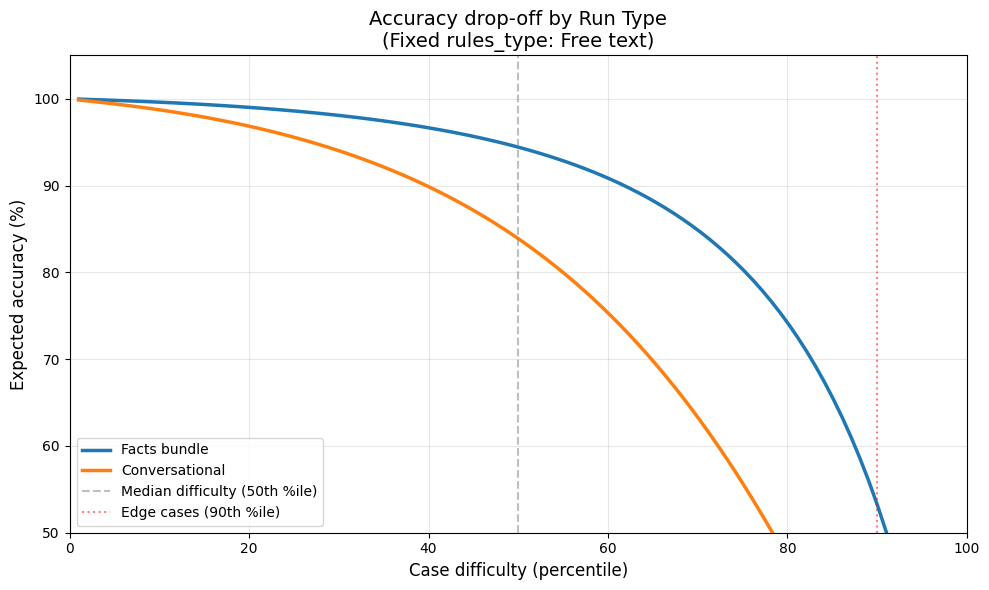

In [22]:
fig_runs, ax_runs, df_runs_curves = plot_accuracy_dropoff_by_difficulty(
    idata=idata,
    df=df,
    main_var="run_type",
    fixed_var="rules_type",
    fixed_level="Free text",
    title="Accuracy drop-off by Run Type"
)

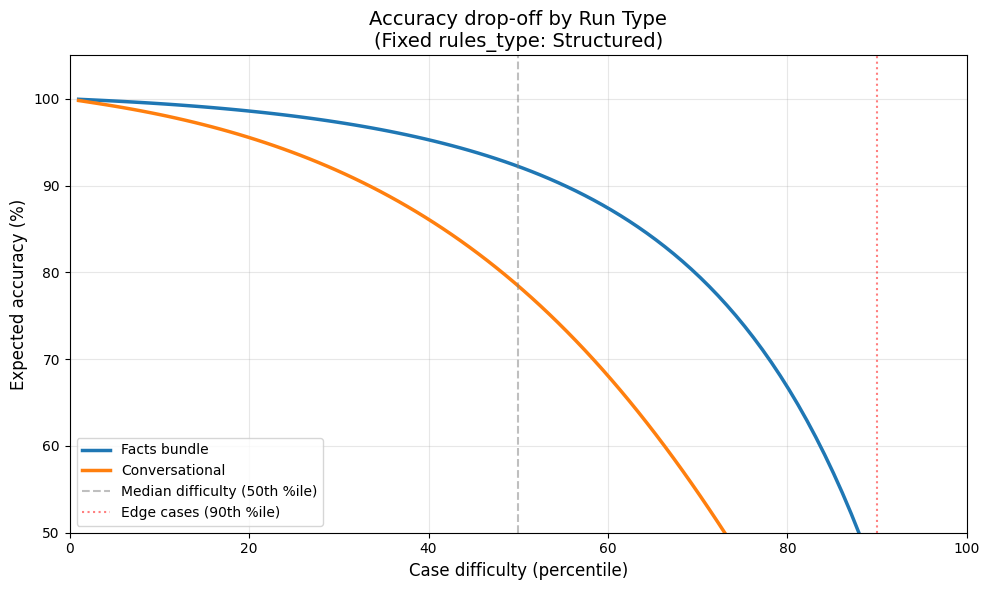

In [23]:
fig_runs, ax_runs, df_runs_curves = plot_accuracy_dropoff_by_difficulty(
    idata=idata,
    df=df,
    main_var="run_type",
    fixed_var="rules_type",
    fixed_level="Structured",
    title="Accuracy drop-off by Run Type"
)

In [24]:
df["run_type"].value_counts()

run_type
Facts bundle      3492
Conversational    3492
Name: count, dtype: int64

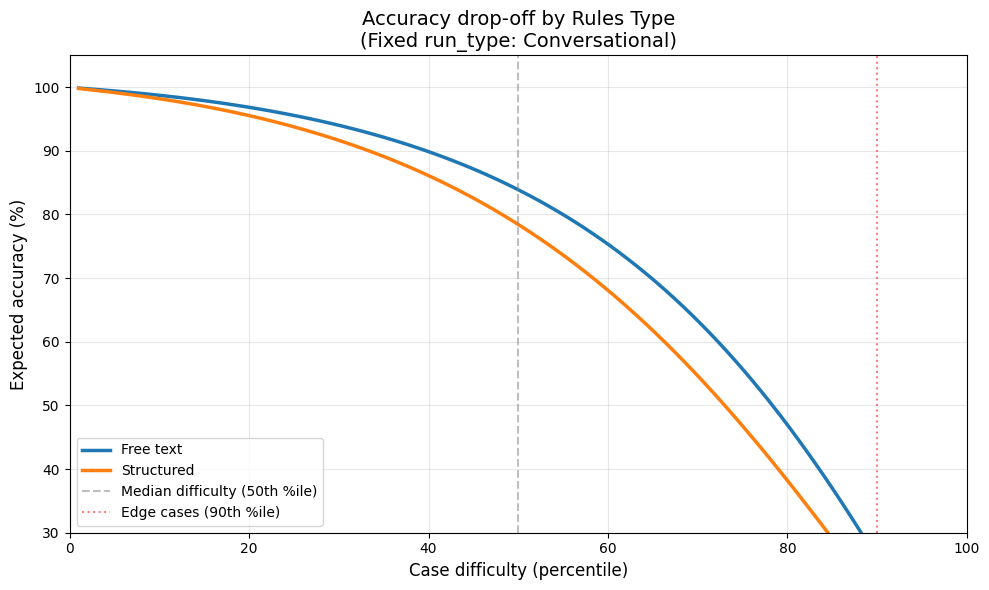

In [25]:

fig_rules, ax_rules, df_rules_curves = plot_accuracy_dropoff_by_difficulty(
    idata=idata,
    df=df,
    main_var="rules_type",
    fixed_var="run_type",
    fixed_level="Conversational",
    title="Accuracy drop-off by Rules Type",
    ylim=(30, 105)
)

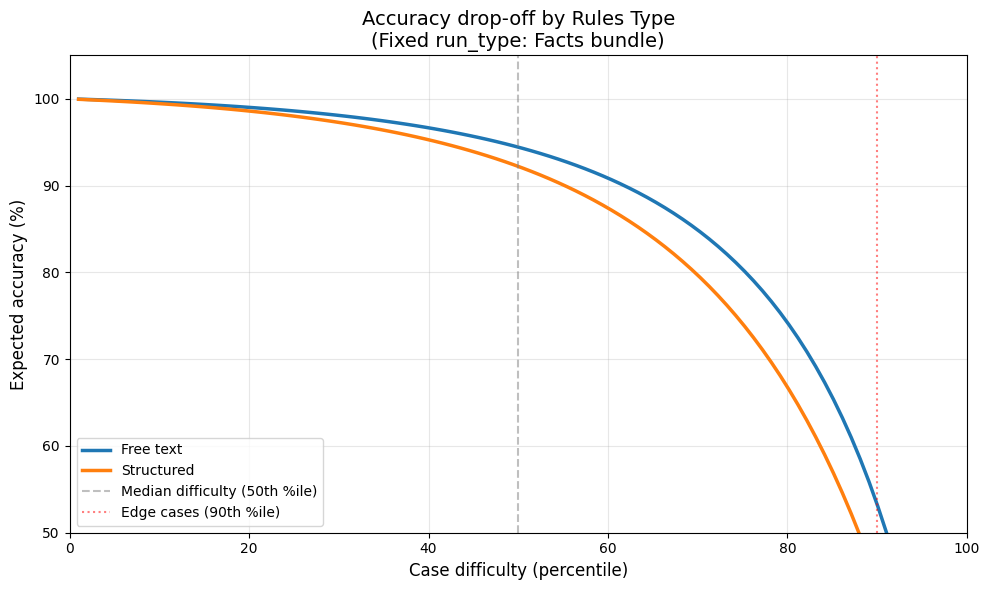

In [26]:

fig_rules, ax_rules, df_rules_curves = plot_accuracy_dropoff_by_difficulty(
    idata=idata,
    df=df,
    main_var="rules_type",
    fixed_var="run_type",
    fixed_level="Facts bundle",
    title="Accuracy drop-off by Rules Type",
    ylim = (50, 105)
)

In [27]:
from scipy.stats import gaussian_kde

def plot_mean_accuracy_distributions(
    idata,
    df: pd.DataFrame,
    *,
    main_var: str = "run_type",
    fixed_var: str = "rules_type",
    figsize=(10, 6),
    xlim=None,
):
    """
    Plot posterior distributions of mean predicted accuracy across observed cases,
    separately for each level of the fixed_var.

    For each posterior draw, predicted probabilities are computed for all observed
    cases and then averaged across cases. The KDE is then drawn over those
    draw-level mean accuracies.

    Returns
    -------
    figs : dict
        Mapping of fixed_var level -> matplotlib figure
    plot_data : dict
        Nested dict of fixed_var level -> main_var level -> draw-level mean predicted accuracies
    """
    posterior = idata.posterior

    # ==========================================
    # 1. Identify levels and validate dimensions
    # ==========================================
    main_levels = df[main_var].dropna().unique()
    fixed_levels = df[fixed_var].dropna().unique()

    main_dim = f"{main_var}_dim"
    fixed_dim = f"{fixed_var}_dim"

    # Safely identify which levels are actually in the posterior
    if main_var in posterior and main_dim in posterior[main_var].coords:
        posterior_main_levels = posterior[main_var].coords[main_dim].values.tolist()
    else:
        posterior_main_levels = []

    if fixed_var in posterior and fixed_dim in posterior[fixed_var].coords:
        posterior_fixed_levels = posterior[fixed_var].coords[fixed_dim].values.tolist()
    else:
        posterior_fixed_levels = []

    # ==========================================
    # 2. Extract shared parameters (case variance & zeroes array)
    # ==========================================
    n_draws = posterior.sizes["chain"] * posterior.sizes["draw"]
    zeros = np.zeros(n_draws)
    
    # Random intercepts for cases
    case_effects = posterior["1|case_id"].values.reshape(n_draws, -1)

    plot_data = {}
    all_kde_maxima = []

    # ==========================================
    # 3. Compute distributions and shared y-limit
    # ==========================================
    for f_level in fixed_levels:
        plot_data[f_level] = {}

        # Safely extract the fixed effect (or 0 if baseline)
        if f_level in posterior_fixed_levels:
            fixed_effect = posterior[fixed_var].sel({fixed_dim: f_level}).values.reshape(-1)
        else:
            fixed_effect = zeros

        for m_level in main_levels:
            # Safely extract the main effect (or 0 if baseline)
            if m_level in posterior_main_levels:
                main_effect = posterior[main_var].sel({main_dim: m_level}).values.reshape(-1)
            else:
                main_effect = zeros

            # Calculate predicted probabilities for all cases at this posterior draw
            # Broadcasting: (n_draws, 1) + (n_draws, 1) + (n_draws, n_cases)
            log_odds = main_effect[:, None] + fixed_effect[:, None] + case_effects
            predicted_probs = expit(log_odds) * 100

            # Mean predicted accuracy across cases for each posterior draw
            mean_accuracy = predicted_probs.mean(axis=1)
            plot_data[f_level][m_level] = mean_accuracy

            # Calculate KDE so we can enforce a unified Y-axis limit across all plots
            kde = gaussian_kde(mean_accuracy)
            xs = np.linspace(mean_accuracy.min(), mean_accuracy.max(), 200)
            ys = kde(xs)
            all_kde_maxima.append(ys.max())

    shared_ylim = max(all_kde_maxima) * 1.1

    # ==========================================
    # 4. Plot separate figures
    # ==========================================
    figs = {}

    for f_level in fixed_levels:
        fig, ax = plt.subplots(figsize=figsize)

        for m_level in main_levels:
            sns.kdeplot(
                plot_data[f_level][m_level],
                ax=ax,
                label=str(m_level),
                fill=True,
                alpha=0.35,
                linewidth=2,
            )

        ax.set_title(f"Mean Predicted Accuracy\n(Fixed {fixed_var}: {f_level})", fontsize=14)
        ax.set_xlabel("Mean predicted accuracy across observed cases (%)", fontsize=12)
        ax.set_ylabel("Density", fontsize=11)

        if xlim is not None:
            ax.set_xlim(*xlim)

        ax.set_ylim(0, shared_ylim)
        ax.legend(title=main_var, fontsize=10, title_fontsize=11, loc="upper left")
        ax.grid(True, alpha=0.3)

        plt.tight_layout()
        figs[f_level] = fig
        plt.show()

    return figs, plot_data

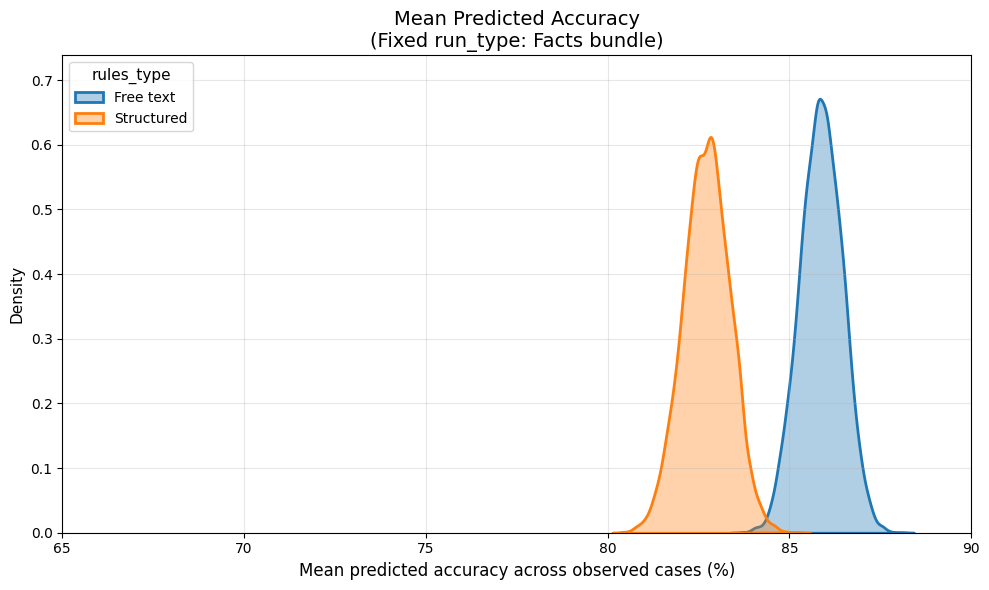

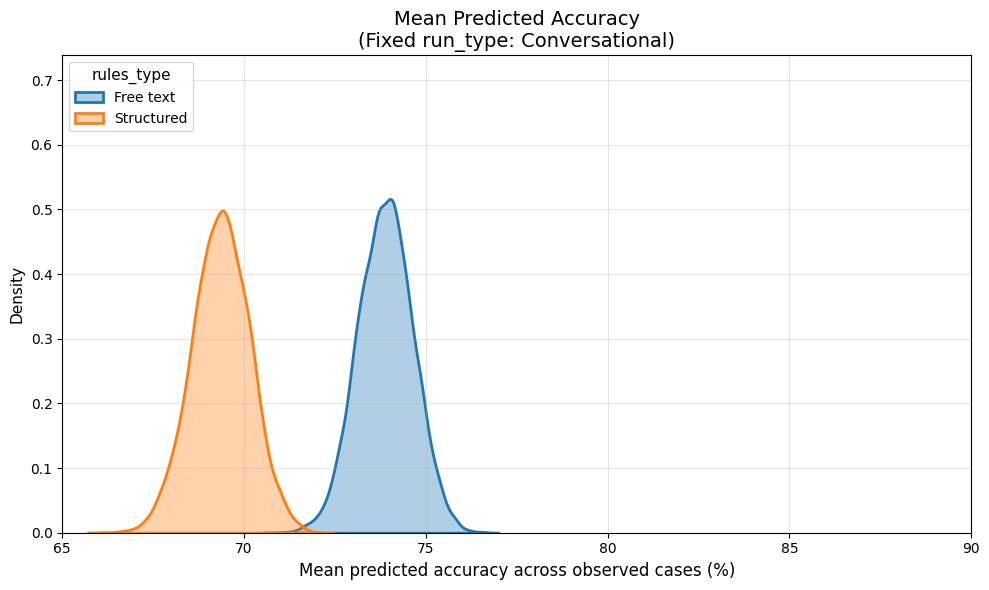

In [28]:
figs, plot_data = plot_mean_accuracy_distributions(
    idata=idata, 
    df=df, 
    main_var="rules_type", 
    fixed_var="run_type",
    xlim=(65, 90)
)